In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [28]:
df = pd.read_csv('Mall_Customers.csv')

In [29]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


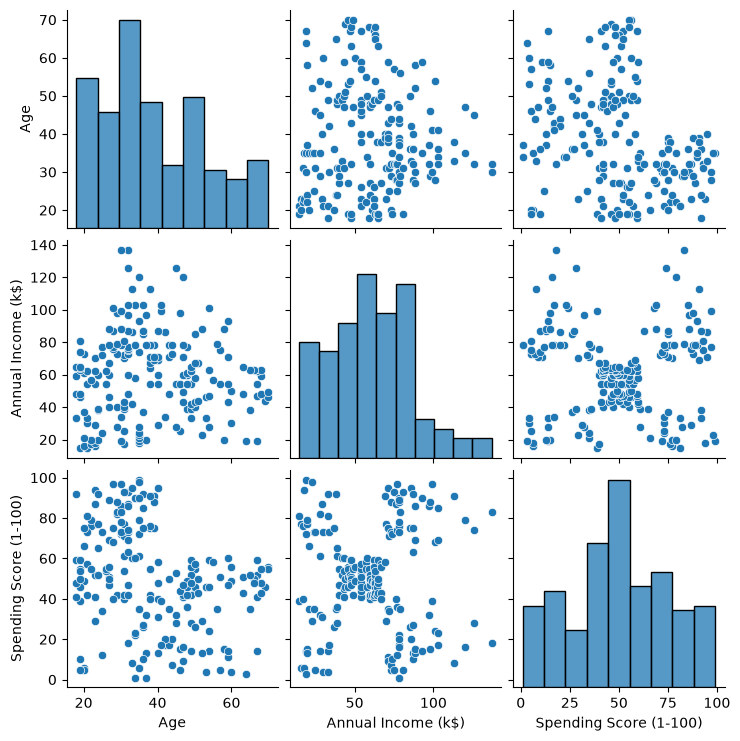

In [30]:
columns = ['Gender','Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sns.pairplot(df[[i for i in columns]], diag_kind = 'hist')

As we can see, spending score and annual income are the most promising features for clustering, as together they reveal 5 distinct customer segments

# K-means Clustering 

In [33]:
X = df[['Annual Income (k$)','Spending Score (1-100)']].values

In [38]:
## Transform X
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_scaled = scale.fit_transform(X)


In [ ]:
## Elbow method (tightness)
from sklearn.cluster import KMeans
wcss = [] 
for k in range(1,11): 
    kmeans = KMeans(n_clusters = k, init = 'k-means++') 
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    

In [40]:
wcss

[400.0,
 274.09061284029747,
 157.70400815035947,
 109.22822707921345,
 65.56840815571681,
 57.389315938509995,
 54.03110691047667,
 51.78856391506637,
 32.33081392367576,
 29.26994752156501]

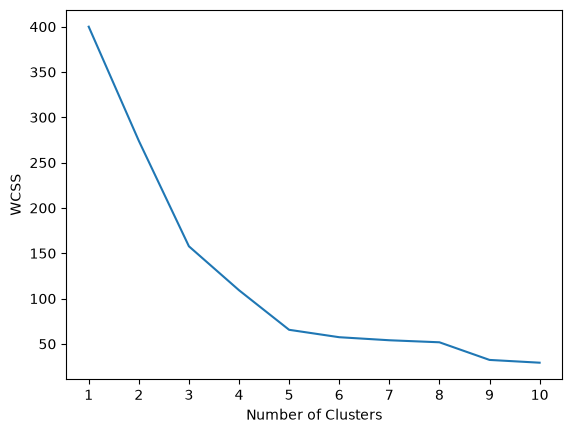

In [41]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

This is not fuzzy elbow. We can cleary see that the sharp bend occurs when k=5

Main reason of fuzzy elbow: 
- poorly-separated clusters
- soft/continuous data structure (data structure that has no clear gaps or boundaries (no cut points))

In [44]:
### Validating K using Silhouette Score 
from sklearn.metrics import silhouette_score
silhouette_coef = [] 
for k in range(2,11): 
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_coef.append(score)
silhouette_coef

[0.38665872527050493,
 0.46658474419000145,
 0.40768242128503873,
 0.5546571631111091,
 0.5378290321306309,
 0.4533660486089094,
 0.4541279523637649,
 0.4402209792252572,
 0.45039692140091164]

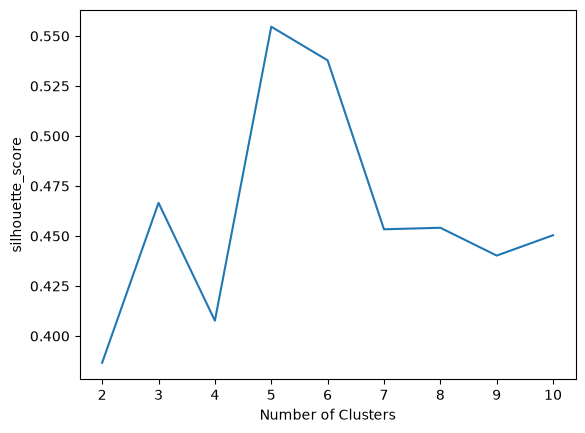

In [45]:
plt.plot(range(2,11),silhouette_coef)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters')
plt.ylabel('silhouette_score')
plt.show()

Silhouette score (separation and tightness): k=5 --> highest score 

In [ ]:
### Fit k=5 and predict the unseen data
kmeans = KMeans(n_clusters = 5, init = 'k-means++')

In [48]:
labels = kmeans.fit_predict(X_scaled)

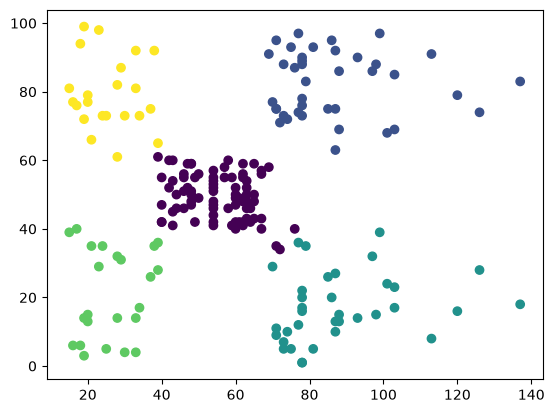

In [53]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c = labels)